**Configuration note:** this notebook examines the purge_dup results for Supplemental Figure S13. Input paths below mirror `config.sh` at the repo root — edit them for your own data. The primary input is `dups.bed` (purge_dups output: HAPLOTIG / HIGHCOV / JUNK / OVLP / REPEAT).


In [5]:
# Input paths — edit for your environment (mirror config.sh at the repo root).
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"
DUP_BED   = f"{PROJ_ROOT}/output/outputs-from-purge-duplicate/hifiasm-041425-scaffolded-assembly/dups.bed"


# Gene overlap with purge_dups sequence categories

**Purpose**: Quantify the number of annotated genes that fall within each
purge_dups sequence category, stratified by paralog status: singletons
(no paralog family), reference genes (parents in paralog families),
and paralog copies.

**Data sources**:
- `dups.bed` — purge_dups output: 245 regions across 5 categories (151.9 Mb total)
- `paralog_families.tsv` — 3,272 genes assigned to paralog families (1,091 parents + 2,181 paralogs)
- `hifiasm-041425-denovoEnhanced_peaks2utr_sorted.agat.gff3` — full annotation: 26,273 genes

**Method**: Genes were classified into categories by cross-referencing the
full GFF3 annotation with paralog family membership. Bedtools intersect was
used to identify genes whose coordinates overlap each purge_dups region type.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.font_manager import FontProperties
import re
import textwrap
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Publication-style settings
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'legend.fontsize': 8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [7]:
# ===========================================================================
# Data — bedtools intersect of GFF3 genes vs each purge_dups category BED
# ===========================================================================

TOTAL_GENES = 26273

# Purge_dups categories (region count, total Mb)
purge_cats = {
    'HAPLOTIG': {'n_regions': 28, 'bp_mb': 12.09},
    'HIGHCOV':  {'n_regions':  2, 'bp_mb':  0.07},
    'JUNK':     {'n_regions': 22, 'bp_mb':  0.26},
    'OVLP':     {'n_regions': 26, 'bp_mb': 11.65},
    'REPEAT':   {'n_regions': 167,'bp_mb': 127.86},
}

# Gene category definitions with overlap counts per purge_dups category
# Each sub-category has: total, and counts for each purge_dup type
categories = {
    'singleton': {
        'label': 'Singleton',
        'total': 23001,
        'color': '#3498DB',
        'overlap': {'HAPLOTIG': 1, 'HIGHCOV': 0, 'JUNK': 0, 'OVLP': 34, 'REPEAT': 9},
    },
    'parent': {
        'label': 'Reference gene',
        'total': 1091,
        'color': '#2ECC40',
        'overlap': {'HAPLOTIG': 0, 'HIGHCOV': 0, 'JUNK': 0, 'OVLP': 0, 'REPEAT': 0},
    },
    'paralog_l': {
        'label': 'paralog_l (Liftoff-only)',
        'total': 972,
        'color': '#E67E22',
        'overlap': {'HAPLOTIG': 0, 'HIGHCOV': 0, 'JUNK': 0, 'OVLP': 4, 'REPEAT': 1},
    },
    'paralog_dl': {
        'label': 'paralog_dl (de novo + Liftoff)',
        'total': 1202,
        'color': '#E74C3C',
        'overlap': {'HAPLOTIG': 2, 'HIGHCOV': 0, 'JUNK': 0, 'OVLP': 8, 'REPEAT': 27},
    },
    'paralog_rl': {
        'label': 'paralog_rl (reference-linked Liftoff)',
        'total': 7,
        'color': '#9B59B6',
        'overlap': {'HAPLOTIG': 0, 'HIGHCOV': 0, 'JUNK': 0, 'OVLP': 0, 'REPEAT': 0},
    },
}

# Compute derived totals
total_paralog = sum(categories[k]['total'] for k in ['paralog_l', 'paralog_dl', 'paralog_rl'])
total_reference = categories['parent']['total']
total_paralogous = total_paralog + total_reference
total_singleton = categories['singleton']['total']

# Sum overlap counts across sub-categories for grouped rows
def sum_overlap(*keys):
    result = {}
    for pc in purge_cats:
        result[pc] = sum(categories[k]['overlap'][pc] for k in keys)
    return result

def sum_overlap_all():
    result = {}
    for pc in purge_cats:
        result[pc] = sum(categories[k]['overlap'][pc] for k in categories)
    return result

overlap_paralog = sum_overlap('paralog_l', 'paralog_dl', 'paralog_rl')
overlap_paralogous = sum_overlap('parent', 'paralog_l', 'paralog_dl', 'paralog_rl')
overlap_all = sum_overlap_all()

# Validation
assert total_singleton + total_paralogous == TOTAL_GENES
assert total_paralog == 2181

# Print summary
print(f'Total annotated genes: {TOTAL_GENES:,}')
print(f'  Singleton:              {total_singleton:,}')
print(f'  Paralogous genes:       {total_paralogous:,}')
print(f'    Reference gene:       {total_reference:,}')
print(f'    Paralog copy:         {total_paralog:,}')
print(f'      paralog_l:          {categories["paralog_l"]["total"]:,}')
print(f'      paralog_dl:         {categories["paralog_dl"]["total"]:,}')
print(f'      paralog_rl:         {categories["paralog_rl"]["total"]:,}')
print(f'\nPurge_dups categories:')
for pc in purge_cats:
    info = purge_cats[pc]
    print(f'  {pc:<12s} {info["n_regions"]:>4d} regions, {info["bp_mb"]:>7.2f} Mb')
print(f'\nOverlap summary (total overlapping genes):')
for pc in purge_cats:
    print(f'  {pc:<12s} {overlap_all[pc]:>4d}')

Total annotated genes: 26,273
  Singleton:              23,001
  Paralogous genes:       3,272
    Reference gene:       1,091
    Paralog copy:         2,181
      paralog_l:          972
      paralog_dl:         1,202
      paralog_rl:         7

Purge_dups categories:
  HAPLOTIG       28 regions,   12.09 Mb
  HIGHCOV         2 regions,    0.07 Mb
  JUNK           22 regions,    0.26 Mb
  OVLP           26 regions,   11.65 Mb
  REPEAT        167 regions,  127.86 Mb

Overlap summary (total overlapping genes):
  HAPLOTIG        3
  HIGHCOV         0
  JUNK            0
  OVLP           46
  REPEAT         37


## Summary table — Gene overlap with purge_dups sequence categories

Genes are stratified by paralog status: singletons (no paralog family),
reference genes, and paralog copies (split by annotation source).
Each purge_dups category column reports the number of genes of that type
whose coordinates overlap regions assigned to that category.

Saved: haplotig_gene_overlap_table.png
Saved: haplotig_gene_overlap_table.pdf


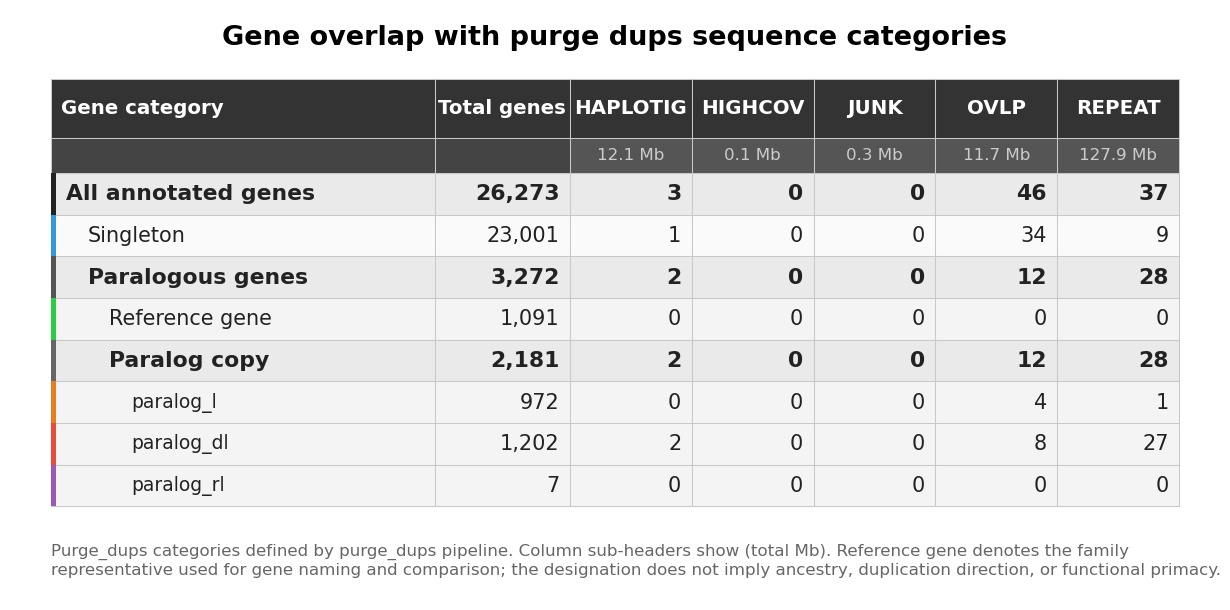

In [8]:
# ===========================================================================
# Publication-ready table — genes overlapping each purge_dups category
# Follows the style of category_exploration_v4_busco.ipynb
# ===========================================================================

# ---------------------------------------------------------------------------
# Table row definitions
#
# level: nesting depth (0 = top, 1 = major group, 2 = sub-group, 3 = leaf)
# is_group: True for summary/header rows that don't appear at lowest level
# ---------------------------------------------------------------------------

purge_cat_order = ['HAPLOTIG', 'HIGHCOV', 'JUNK', 'OVLP', 'REPEAT']

table_rows = [
    # (label, total, overlap_dict, level, is_group, color)
    ('All annotated genes', TOTAL_GENES, overlap_all, 0, True, '#222222'),
    ('Singleton', total_singleton, categories['singleton']['overlap'],
     1, False, categories['singleton']['color']),
    ('Paralogous genes', total_paralogous, overlap_paralogous,
     1, True, '#555555'),
    ('Reference gene', total_reference, categories['parent']['overlap'],
     2, False, categories['parent']['color']),
    ('Paralog copy', total_paralog, overlap_paralog,
     2, True, '#666666'),
    ('paralog_l', categories['paralog_l']['total'], categories['paralog_l']['overlap'],
     3, False, categories['paralog_l']['color']),
    ('paralog_dl', categories['paralog_dl']['total'], categories['paralog_dl']['overlap'],
     3, False, categories['paralog_dl']['color']),
    ('paralog_rl', categories['paralog_rl']['total'], categories['paralog_rl']['overlap'],
     3, False, categories['paralog_rl']['color']),
]

# ---------------------------------------------------------------------------
# Column definitions
# Gene category | Total genes | HAPLOTIG | HIGHCOV | JUNK | OVLP | REPEAT
# ---------------------------------------------------------------------------

col_labels = ['Gene category', 'Total genes'] + purge_cat_order

# Must sum to 1.0
col_widths = [0.34, 0.12] + [0.108] * 5

assert abs(sum(col_widths) - 1.0) < 1e-8

# ---------------------------------------------------------------------------
# Column sub-headers (region count + Mb per purge_dups category)
# ---------------------------------------------------------------------------

col_subheaders = ['', '']
for pc in purge_cat_order:
    info = purge_cats[pc]
    col_subheaders.append(f'{info["bp_mb"]:.1f} Mb')

# ---------------------------------------------------------------------------
# Figure and typography
# ---------------------------------------------------------------------------

FIGURE_WIDTH_IN = 8.0

TITLE_FONTSIZE = 13
HEADER_FONTSIZE = 9.5
SUBHEADER_FONTSIZE = 8
GROUP_FONTSIZE = 10.5
BODY_FONTSIZE = 10
BODY_FONTSIZE_SMALL = 9
FOOTNOTE_FONTSIZE = 8

BODY_LINE_SPACING = 1.02

HORIZONTAL_PADDING_PT = 5.0
VERTICAL_PADDING_PT = 4.0

HEADER_HEIGHT_PT = 28.0
SUBHEADER_HEIGHT_PT = 17.0

TOP_MARGIN_PT = 5.0
TITLE_HEIGHT_PT = 20.0
TITLE_TABLE_GAP_PT = 6.0
BOTTOM_MARGIN_PT = 5.0

TABLE_LEFT = 0.03
TABLE_WIDTH = 0.94

HEADER_BACKGROUND = '#333333'
BODY_BACKGROUND = '#FAFAFA'
GROUP_BACKGROUND = '#EAEAEA'
SUBROW_BACKGROUND = '#F4F4F4'
GRID_COLOR = '#C8C8C8'
GRID_LINEWIDTH = 0.5

INDENT_PER_LEVEL = 0.018
ACCENT_WIDTH = 0.004

# ---------------------------------------------------------------------------
# Font properties
# ---------------------------------------------------------------------------

header_font = FontProperties(family='sans-serif', size=HEADER_FONTSIZE, weight='bold')
subheader_font = FontProperties(family='sans-serif', size=SUBHEADER_FONTSIZE, weight='normal')
group_font = FontProperties(family='sans-serif', size=GROUP_FONTSIZE, weight='bold')
body_font = FontProperties(family='sans-serif', size=BODY_FONTSIZE, weight='normal')
body_font_small = FontProperties(family='sans-serif', size=BODY_FONTSIZE_SMALL, weight='normal')
title_font = FontProperties(family='sans-serif', size=TITLE_FONTSIZE, weight='bold')
footnote_font = FontProperties(family='sans-serif', size=FOOTNOTE_FONTSIZE, weight='normal')

# ---------------------------------------------------------------------------
# Text measuring helpers
# ---------------------------------------------------------------------------

def normalize_text(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def rendered_text_width(renderer, text, font_properties):
    width, _, _ = renderer.get_text_width_height_descent(text, font_properties, ismath=False)
    return width

# ---------------------------------------------------------------------------
# Build row data structures
# ---------------------------------------------------------------------------

row_data = []
for label, total, overlap_dict, level, is_group, color in table_rows:
    if total is not None:
        total_str = f'{total:,}'
    else:
        total_str = ''
    
    overlap_values = []
    for pc in purge_cat_order:
        val = overlap_dict[pc]
        overlap_values.append(f'{val:,}')
    
    row_data.append({
        'label': label,
        'total': total_str,
        'overlap_values': overlap_values,
        'level': level,
        'is_group': is_group,
        'color': color,
    })

# ---------------------------------------------------------------------------
# Create temporary figure to measure text
# ---------------------------------------------------------------------------

fig = plt.figure(figsize=(FIGURE_WIDTH_IN, 7.0), facecolor='white')
ax_table = fig.add_axes([0, 0, 1, 1])
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)
ax_table.axis('off')
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

figure_width_px = FIGURE_WIDTH_IN * fig.dpi
table_width_px = figure_width_px * TABLE_WIDTH
horizontal_padding_px = HORIZONTAL_PADDING_PT / 72.0 * fig.dpi

# ---------------------------------------------------------------------------
# Wrap cell text to fit column width
# ---------------------------------------------------------------------------

def wrap_cell(text, max_width_px, font_prop):
    text = normalize_text(text)
    if not text:
        return '', 0
    words = text.split()
    lines = []
    current = words[0]
    for word in words[1:]:
        candidate = f'{current} {word}'
        if rendered_text_width(renderer, candidate, font_prop) <= max_width_px:
            current = candidate
        else:
            lines.append(current)
            current = word
    lines.append(current)
    return '\n'.join(lines), len(lines)

wrapped_rows = []
row_line_counts = []

for rd in row_data:
    # Column 0: category label
    cell0_width_px = table_width_px * col_widths[0]
    label_indent = rd['level'] * INDENT_PER_LEVEL
    avail0_px = cell0_width_px - 2 * horizontal_padding_px - label_indent * figure_width_px * TABLE_WIDTH - 4
    
    if rd['is_group'] and rd['level'] <= 1:
        fp0 = group_font
    elif rd['is_group']:
        fp0 = group_font
    elif rd['level'] >= 3:
        fp0 = body_font_small
    else:
        fp0 = body_font
    
    label_wrapped, label_lines = wrap_cell(rd['label'], avail0_px, fp0)
    max_lines = max(label_lines, 1)
    
    wrapped_values = [label_wrapped]
    
    # Column 1: Total genes
    cell1_width_px = table_width_px * col_widths[1]
    avail1_px = cell1_width_px - 2 * horizontal_padding_px - 4
    fp1 = group_font if rd['is_group'] else body_font
    total_wrapped, total_lines = wrap_cell(rd['total'], avail1_px, fp1)
    wrapped_values.append(total_wrapped)
    max_lines = max(max_lines, total_lines)
    
    # Columns 2-6: Overlap counts
    for ci, val in enumerate(rd['overlap_values']):
        cell_w_px = table_width_px * col_widths[ci + 2]
        avail_px = cell_w_px - 2 * horizontal_padding_px - 4
        fp = group_font if rd['is_group'] else body_font
        v_wrapped, v_lines = wrap_cell(val, avail_px, fp)
        wrapped_values.append(v_wrapped)
        max_lines = max(max_lines, v_lines)
    
    wrapped_rows.append(wrapped_values)
    row_line_counts.append(max_lines)

# ---------------------------------------------------------------------------
# Calculate row heights
# ---------------------------------------------------------------------------

body_line_height_pt = BODY_FONTSIZE * 1.15
row_heights_pt = [
    max(line_count * body_line_height_pt + 2 * VERTICAL_PADDING_PT, 20.0)
    for line_count in row_line_counts
]
table_height_pt = HEADER_HEIGHT_PT + SUBHEADER_HEIGHT_PT + sum(row_heights_pt)
figure_height_pt = TOP_MARGIN_PT + TITLE_HEIGHT_PT + TITLE_TABLE_GAP_PT + table_height_pt + BOTTOM_MARGIN_PT
figure_height_in = figure_height_pt / 72.0

fig.set_size_inches(FIGURE_WIDTH_IN, figure_height_in, forward=True)
fig.canvas.draw()

# ---------------------------------------------------------------------------
# Convert points to axes fractions
# ---------------------------------------------------------------------------

def pt_to_y(pt):
    return pt / figure_height_pt

title_y = 1.0 - pt_to_y(TOP_MARGIN_PT)
table_top = 1.0 - pt_to_y(TOP_MARGIN_PT + TITLE_HEIGHT_PT + TITLE_TABLE_GAP_PT)
header_height_frac = pt_to_y(HEADER_HEIGHT_PT)
subheader_height_frac = pt_to_y(SUBHEADER_HEIGHT_PT)
row_heights_frac = [pt_to_y(h) for h in row_heights_pt]
horizontal_padding_frac = HORIZONTAL_PADDING_PT / 72.0 / FIGURE_WIDTH_IN

# ---------------------------------------------------------------------------
# Column boundaries
# ---------------------------------------------------------------------------

col_lefts = [TABLE_LEFT]
running = TABLE_LEFT
for w in col_widths[:-1]:
    running += TABLE_WIDTH * w
    col_lefts.append(running)
col_display_widths = [TABLE_WIDTH * w for w in col_widths]

# ---------------------------------------------------------------------------
# Draw title
# ---------------------------------------------------------------------------

ax_table.text(
    0.5, title_y,
    'Gene overlap with purge dups sequence categories',
    fontproperties=title_font, ha='center', va='top', color='black')

# ---------------------------------------------------------------------------
# Draw header row
# ---------------------------------------------------------------------------

header_bottom = table_top - header_height_frac

for ci, label in enumerate(col_labels):
    cell_left = col_lefts[ci]
    cell_width = col_display_widths[ci]
    
    ax_table.add_patch(Rectangle(
        (cell_left, header_bottom), cell_width, header_height_frac,
        facecolor=HEADER_BACKGROUND, edgecolor=GRID_COLOR, linewidth=GRID_LINEWIDTH))
    
    if ci == 0:
        tx = cell_left + horizontal_padding_frac
        ha = 'left'
    else:
        tx = cell_left + cell_width / 2
        ha = 'center'
    
    ax_table.text(tx, header_bottom + header_height_frac / 2,
        label, fontproperties=header_font, color='white', ha=ha, va='center')

# ---------------------------------------------------------------------------
# Draw sub-header row (region count + Mb)
# ---------------------------------------------------------------------------

subheader_bottom = header_bottom - subheader_height_frac

for ci, label in enumerate(col_subheaders):
    cell_left = col_lefts[ci]
    cell_width = col_display_widths[ci]
    
    if ci < 2:
        bg = '#444444'
    else:
        bg = '#555555'
    
    ax_table.add_patch(Rectangle(
        (cell_left, subheader_bottom), cell_width, subheader_height_frac,
        facecolor=bg, edgecolor=GRID_COLOR, linewidth=GRID_LINEWIDTH))
    
    if ci == 0:
        tx = cell_left + horizontal_padding_frac
        ha = 'left'
    else:
        tx = cell_left + cell_width / 2
        ha = 'center'
    
    ax_table.text(tx, subheader_bottom + subheader_height_frac / 2,
        label, fontproperties=subheader_font, color='#CCCCCC', ha=ha, va='center')

# ---------------------------------------------------------------------------
# Draw body rows
# ---------------------------------------------------------------------------

current_top = subheader_bottom

for ri, (rd, wrapped) in enumerate(zip(row_data, wrapped_rows)):
    row_height = row_heights_frac[ri]
    row_bottom = current_top - row_height
    
    # Row background
    if rd['is_group']:
        bg = GROUP_BACKGROUND
    elif rd['level'] >= 2:
        bg = SUBROW_BACKGROUND
    else:
        bg = BODY_BACKGROUND
    
    # Draw all cell backgrounds first
    for ci in range(len(col_labels)):
        cell_left = col_lefts[ci]
        cell_width = col_display_widths[ci]
        ax_table.add_patch(Rectangle(
            (cell_left, row_bottom), cell_width, row_height,
            facecolor=bg, edgecolor=GRID_COLOR, linewidth=GRID_LINEWIDTH, zorder=0))
    
    # Colored accent bar on the left
    ax_table.add_patch(Rectangle(
        (TABLE_LEFT, row_bottom), ACCENT_WIDTH, row_height,
        facecolor=rd['color'], edgecolor='none', zorder=1))
    
    # Column 0: Category label
    if rd['is_group']:
        fp = group_font
    elif rd['level'] >= 3:
        fp = body_font_small
    else:
        fp = body_font
    
    label_x = TABLE_LEFT + horizontal_padding_frac + ACCENT_WIDTH + rd['level'] * INDENT_PER_LEVEL
    ax_table.text(
        label_x, row_bottom + row_height / 2,
        wrapped[0], fontproperties=fp, color='#222222',
        ha='left', va='center', linespacing=BODY_LINE_SPACING, clip_on=True)
    
    # Columns 1-6: Numeric values (right-aligned)
    for ci in range(1, len(col_labels)):
        cell_left = col_lefts[ci]
        cell_width = col_display_widths[ci]
        fp = group_font if rd['is_group'] else body_font
        
        ax_table.text(
            cell_left + cell_width - horizontal_padding_frac,
            row_bottom + row_height / 2,
            wrapped[ci], fontproperties=fp, color='#222222',
            ha='right', va='center', linespacing=BODY_LINE_SPACING, clip_on=True)
    
    current_top = row_bottom

# ---------------------------------------------------------------------------
# Footnote
# ---------------------------------------------------------------------------

footnote_y = current_top - pt_to_y(18)

ax_table.text(
    TABLE_LEFT, footnote_y,
    'Purge_dups categories defined by purge_dups pipeline. Column sub-headers show (total Mb). '
    'Reference gene denotes the family representative used for gene naming and comparison; '
    'the designation does not imply ancestry, duplication direction, or functional primacy.',
    fontproperties=footnote_font, color='#666666',
    ha='left', va='top', wrap=True)

# ---------------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------------

for out_fmt, out_name in [('png', 'haplotig_gene_overlap_table.png'),
                           ('pdf', 'haplotig_gene_overlap_table.pdf')]:
    plt.savefig(out_name, dpi=300, facecolor='white', bbox_inches='tight', pad_inches=0.04)
    print(f'Saved: {out_name}')

plt.show()

## Summary

Purge_dups regions classified as HIGHCOV and JUNK contain zero annotated genes.
HAPLOTIG regions are nearly devoid of genes (3 genes total). OVLP and REPEAT
categories contain the most gene overlaps (46 and 37 genes, respectively),
with paralogs — particularly `paralog_dl` — showing the highest counts.

The key observation is that **reference genes are entirely absent** from all
purge_dups categories (0 / 1,091 across all five types). This suggests that
the reference (parent) gene annotations are placed on well-assembled chromosomal
regions, while paralog copies and a small number of singletons occasionally
fall within regions flagged by purge_dups for potential removal.